In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean visual output
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows
display(df.head())

# Inspect columns, null counts, and data types
print("\n--- DATASET INFORMATION ---")
display(df.info())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- DATASET INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBill

None

In [2]:
# Find rows where TotalCharges is just a blank space
blank_charges = df[df['TotalCharges'] == ' ']

print(f"Found {len(blank_charges)} rows with blank spaces.")
display(blank_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Found 11 rows with blank spaces.


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [3]:
# 1. Convert TotalCharges to numeric, forcing errors (like spaces) to turn into NaN (nulls)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Fill those newly created NaN values with 0 (since tenure is 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Sanity check: Verify the fix
print("--- UPDATED COLUMN INFO ---")
print(df['TotalCharges'].info())

# Show summary statistics of the numeric columns
display(df.describe())

--- UPDATED COLUMN INFO ---
<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB
None


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Exploratory Data Analysis (EDA)

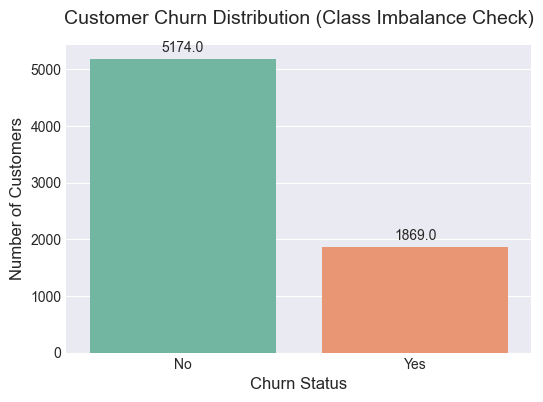

--- BASELINE CHURN RATES ---
Retained (No):  73.5%
Churned (Yes):  26.5%


In [4]:
# --- 1. TARGET VARIABLE DISTRIBUTION ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution (Class Imbalance Check)', fontsize=14, pad=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.show()

# Print precise baseline percentages
churn_rates = df['Churn'].value_counts(normalize=True) * 100
print("--- BASELINE CHURN RATES ---")
print(f"Retained (No):  {churn_rates['No']:.1f}%")
print(f"Churned (Yes):  {churn_rates['Yes']:.1f}%")

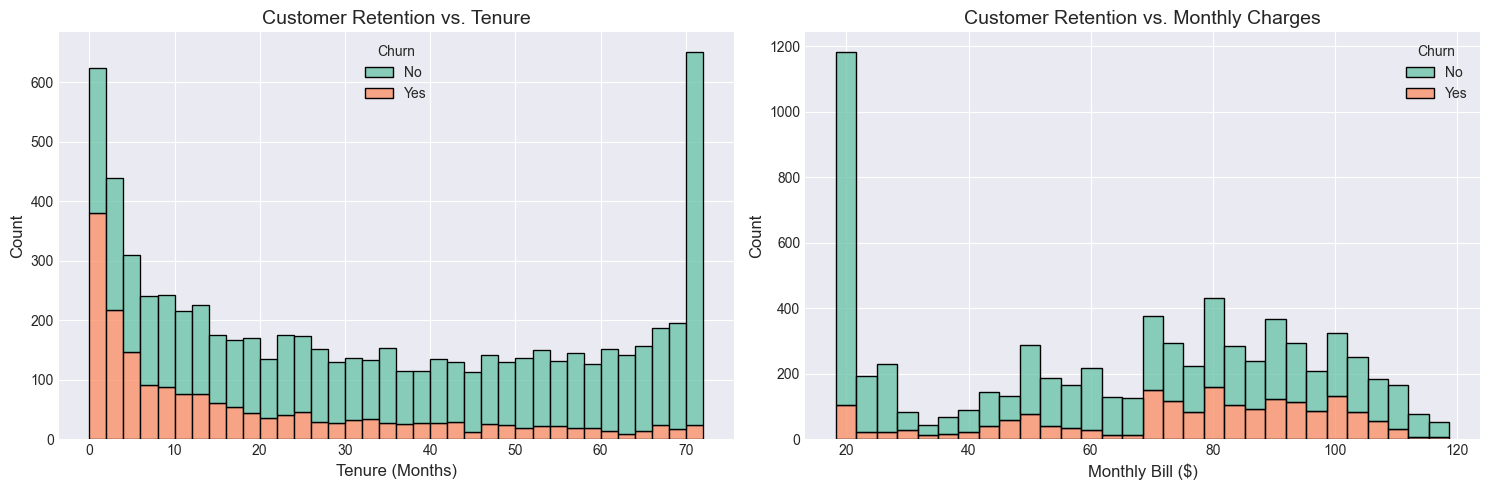

In [5]:
# --- 2. NUMERICAL DRIVERS OF CHURN ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=36, palette='Set2', ax=axes[0])
axes[0].set_title('Customer Retention vs. Tenure', fontsize=14)
axes[0].set_xlabel('Tenure (Months)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Plot 2: Monthly Charges vs Churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30, palette='Set2', ax=axes[1])
axes[1].set_title('Customer Retention vs. Monthly Charges', fontsize=14)
axes[1].set_xlabel('Monthly Bill ($)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

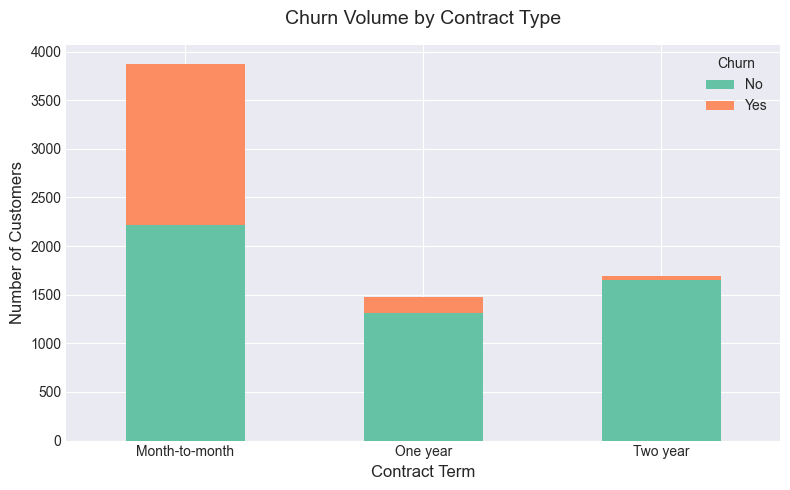

In [6]:
# --- 3. CATEGORICAL DRIVERS: CONTRACT TYPE ---
plt.figure(figsize=(8, 5))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', stacked=True, color=sns.color_palette('Set2'), figsize=(8, 5))

plt.title('Churn Volume by Contract Type', fontsize=14, pad=15)
plt.xlabel('Contract Term', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.tight_layout()
plt.show()

## Feature Engineering & Preprocessing

In [8]:
# Import the missing encoder
from sklearn.preprocessing import LabelEncoder

# --- PREPROCESSING & ENCODING ---
# 1. Drop customerID (has no predictive power)
df_clean = df.drop(columns=['customerID'])

# 2. Map target variable explicitly to integers
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 3. Identify categorical columns
binary_cols = [col for col in df_clean.columns if df_clean[col].nunique() == 2 and col != 'Churn']
multi_cols = [col for col in df_clean.columns if df_clean[col].nunique() > 2 and df_clean[col].dtype == 'object']

# 4. Label Encode binary columns (e.g., 'Gender', 'Partner', 'Dependents')
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# 5. One-Hot Encode multi-class columns (e.g., 'Contract', 'PaymentMethod', 'InternetService')
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Verify final shape and clean columns
print(f"Preprocessed DataFrame Shape: {df_clean.shape}")
display(df_clean.head())

Preprocessed DataFrame Shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## Model Training & Experiment Tracking

Training Set: 5634 rows
Testing Set:  1409 rows



2026/05/11 14:19:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/11 14:19:46 INFO mlflow.store.db.utils: Updating database tables
2026/05/11 14:19:48 INFO mlflow.tracking.fluent: Experiment with name 'Telco_Customer_Churn_XGBoost' does not exist. Creating a new experiment.


--- MODEL EVALUATION: XGBOOST ---
Accuracy Score: 0.7956

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



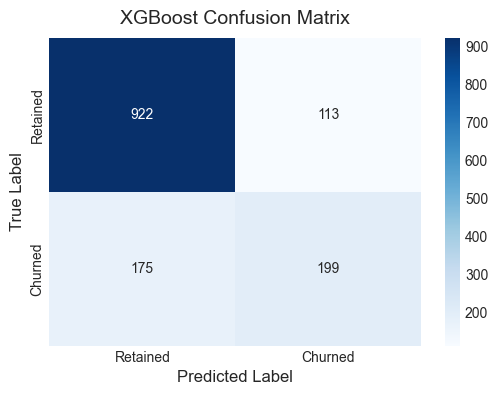

In [9]:
# Import ML modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import mlflow

# --- 1. DEFINE FEATURES AND TARGET ---
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# --- 2. TRAIN-TEST SPLIT (Stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set:  {X_test.shape[0]} rows\n")

# --- 3. SET UP MLFLOW EXPERIMENT ---
mlflow.set_experiment("Telco_Customer_Churn_XGBoost")

# Force boolean columns to integers to ensure native compatibility with XGBoost
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# --- 4. TRAIN AND TRACK MODEL ---
with mlflow.start_run(run_name="Baseline_XGBoost"):
    
    # Define hyperparameters
    params = {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 5,
        'random_state': 42
    }
    
    # Log parameters to MLflow
    mlflow.log_params(params)
    
    # Initialize and train model
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    
    # Generate predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Get probabilities for churn class
    
    # Evaluate performance
    acc = accuracy_score(y_test, y_pred)
    
    # Log metrics to MLflow
    mlflow.log_metric("accuracy", acc)
    
    # Print results
    print(f"--- MODEL EVALUATION: XGBOOST ---")
    print(f"Accuracy Score: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# --- 5. PLOT CONFUSION MATRIX ---
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title('XGBoost Confusion Matrix', fontsize=14, pad=10)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Calculated scale_pos_weight: 2.77

--- OPTIMIZED MODEL EVALUATION ---
Accuracy Score: 0.7502

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Generating SHAP Explanations (This may take a few seconds)...


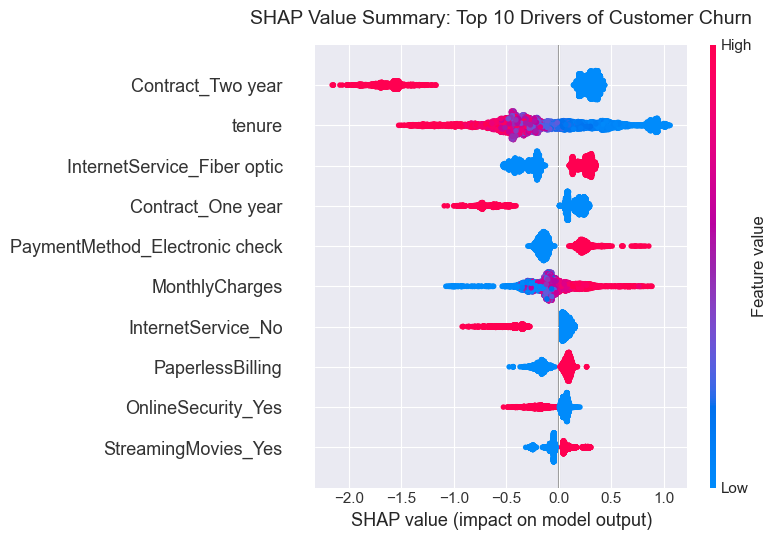

In [11]:
# Import the missing explainability library
import shap
import matplotlib.pyplot as plt

# --- 1. CALCULATE CLASS WEIGHTS ---
# scale_pos_weight = count(negative examples) / count(positive examples)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {scale_weight:.2f}\n")

# --- 2. TRAIN OPTIMIZED MODEL ---
with mlflow.start_run(run_name="Weighted_XGBoost"):
    
    # Updated hyperparameters with class weighting
    opt_params = {
        'n_estimators': 100,
        'learning_rate': 0.05, 
        'max_depth': 4,        
        'scale_pos_weight': scale_weight, 
        'random_state': 42
    }
    
    mlflow.log_params(opt_params)
    
    # Train optimized model
    opt_model = xgb.XGBClassifier(**opt_params)
    opt_model.fit(X_train, y_train)
    
    # Predict
    y_pred_opt = opt_model.predict(X_test)
    acc_opt = accuracy_score(y_test, y_pred_opt)
    mlflow.log_metric("accuracy", acc_opt)
    
    print(f"--- OPTIMIZED MODEL EVALUATION ---")
    print(f"Accuracy Score: {acc_opt:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_opt))

# --- 3. GLOBAL EXPLAINABILITY (SHAP Summary Plot) ---
print("Generating SHAP Explanations (This may take a few seconds)...")
explainer = shap.TreeExplainer(opt_model)
shap_values = explainer(X_train)

# Plot top drivers of churn
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, max_display=10, show=False)
plt.title('SHAP Value Summary: Top 10 Drivers of Customer Churn', fontsize=14, pad=15)
plt.tight_layout()
plt.show()